In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
# Dataset
X, y = make_moons(n_samples=1000, noise=0.3)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
dataset = TensorDataset(X, y)
print(dataset)

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)
len(loader)

32

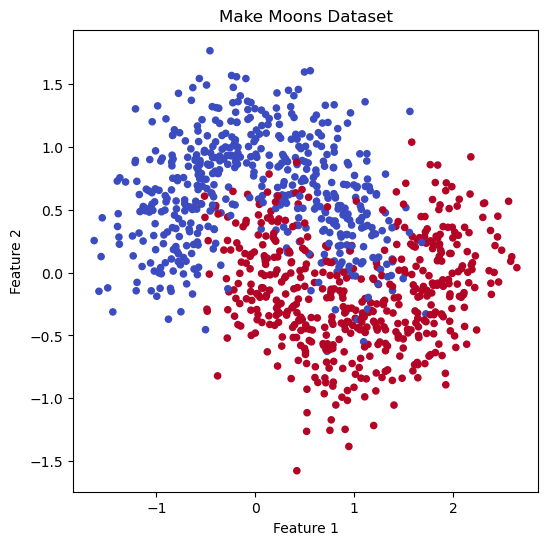

In [ ]:
import matplotlib.pyplot as plt

# Convert tensors to numpy for plotting
X_np = X.numpy()
y_np = y.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(
    X_np[:, 0], X_np[:, 1],
    c=y_np,
    cmap="coolwarm",
    s=20
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Moons Dataset")
plt.show()


In [ ]:
X

tensor([[-0.8652,  0.7075],
        [ 0.1738, -0.2802],
        [-0.2623,  0.4506],
        ...,
        [ 0.9428, -0.5786],
        [-0.0821,  0.8486],
        [-0.0504,  0.2710]])

In [ ]:
y

tensor([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
        0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
        1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
        0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,

# Model Building and Hyperparameter tunning

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train(model, optimizer, epochs=50):
    criterion = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()        # clear old gradients
            preds = model(xb)            # forward
            loss = criterion(preds, yb)  # loss
            loss.backward()              # gradients
            optimizer.step()             # update weights

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(loader))

    return losses

Technique 1: Constant Learning Rate (Baseline)
Logic

Same η throughout training

Simple but inefficient

In [ ]:
model = SimpleNN()
optimizer = optim.SGD(model.parameters(), momentum=0.9, lr=0.1)#momentum=0.9,

losses_constant = train(model, optimizer)
losses_constant

[0.4256418813019991,
 0.33687719982117414,
 0.330528462305665,
 0.3077372252009809,
 0.28482574597001076,
 0.2609490428585559,
 0.24708301154896617,
 0.23707658052444458,
 0.23435236513614655,
 0.22738887183368206,
 0.2176345617044717,
 0.228422193787992,
 0.21923621091991663,
 0.21902294526807964,
 0.21169584593735635,
 0.2217403883114457,
 0.22168543643783778,
 0.21260285592870787,
 0.2519128944259137,
 0.22414855286478996,
 0.2247536750510335,
 0.21503685461357236,
 0.2202437105588615,
 0.22242737002670765,
 0.2141462869476527,
 0.21394981211051345,
 0.209195913746953,
 0.20868542487733066,
 0.21620666165836155,
 0.21679819491691887,
 0.22416091174818575,
 0.2254525136668235,
 0.20891798031516373,
 0.2136407142970711,
 0.2209222948877141,
 0.22028661123476923,
 0.21765937888994813,
 0.20688149612396955,
 0.21523435262497514,
 0.20492725051008165,
 0.2018447876907885,
 0.21537049883045256,
 0.20772100472822785,
 0.21228016016539186,
 0.22120857308618724,
 0.212814788101241,
 0.208198

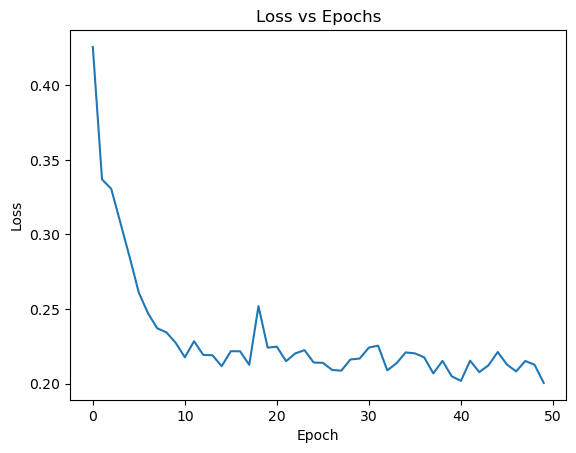

In [ ]:
plt.plot(losses_constant)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Problem

Cannot adapt to loss surface

Often overshoots minima

Technique 2: Small vs Large Learning Rate Comparison

In [ ]:
# Small LR
optimizer_small = optim.SGD(SimpleNN().parameters(), lr=0.001)

# Large LR
optimizer_large = optim.SGD(SimpleNN().parameters(), lr=1.0)


Technique 3: Step Decay Learning Rate
Idea

Reduce LR after fixed number of epochs

ηt=η0
	​

×γ
⌊t/step⌋
| Epoch (t) | ( t/step ) | ⌊t/step⌋ | Learning Rate              |
| --------- | ---------- | -------- | -------------------------- |
| 0–9       | < 1        | 0        | (0.1 \times 0.5^0 = 0.1)   |
| 10–19     | 1.x        | 1        | (0.1 \times 0.5^1 = 0.05)  |
| 20–29     | 2.x        | 2        | (0.1 \times 0.5^2 = 0.025) |
| 30–39     | 3.x        | 3        | (0.0125)                   |


In [ ]:
model = SimpleNN()
optimizer = optim.SGD(model.parameters(), lr=0.1)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    scheduler.step()

Technique 4: Exponential Decay

𝜂
0
𝑒
−
𝑘
𝑡
η
t
	​

=η
0
	​

e
−kt

In [ ]:
scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.95
)

Technique 5: Reduce LR on Plateau (VERY IMPORTANT)
Logic

Monitor validation loss

Reduce LR when improvement stalls

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.02,
    patience=5
)

Used in real projects

Medical

Finance

Vision

Technique 6: Cyclic Learning Rate (Advanced)
Idea

LR oscillates instead of monotonically decreasing

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

scheduler = optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=0.001,
    max_lr=0.1,
    step_size_up=10,
    mode='triangular2'
)


| Mode        | Description        |
| ----------- | ------------------ |
| triangular  | Linear up & down   |
| triangular2 | Decaying amplitude |
| exp_range   | Exponential decay  |


In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100,
    eta_min=1e-5
)


| Technique   | Loss Curve |
| ----------- | ---------- |
| Constant LR | Zig-zag    |
| Step Decay  | Staircase  |
| Plateau     | Adaptive   |
| Cyclic      | Wave-like  |


Real-World Importance
| Area                   | LR Strategy        |
| ---------------------- | ------------------ |
| CNNs                   | ReduceLROnPlateau  |
| Transformers           | Warmup + decay     |
| Medical AI             | Conservative decay |
| Reinforcement Learning | Cyclic / Adaptive  |


# Learning rate controls convergence behavior

# Schedulers improve stability + speed

# Same model + same data → LR alone can change results drastically

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
optimizer = optim.RMSprop(model.parameters(), lr=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001)